**Digit Recognizer (MNIST)**


Persiapan Data & Preprocessing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Load Dataset MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Preprocessing
# a. Normalisasi (0-1)
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# b. Reshape untuk Konvensional (PCA + SVM/RF) -> Flatten menjadi 1D (784 pixel)
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat = X_test_norm.reshape(-1, 784)

# c. Reshape untuk Deep Learning (CNN) -> Tambahkan channel warna (28, 28, 1)
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

print("Shape untuk Konvensional:", X_train_flat.shape)
print("Shape untuk CNN:", X_train_cnn.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape untuk Konvensional: (60000, 784)
Shape untuk CNN: (60000, 28, 28, 1)


Baseline Model Konvensional (PCA + SVM & PCA + Random Forest)

In [ ]:
# Ekstraksi Fitur dengan PCA (Mempertahankan 95% varians)
print("Mengekstraksi fitur dengan PCA...")
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)
print(f"Dimensi direduksi dari 784 menjadi {X_train_pca.shape[1]} komponen utama.")

# --- Kombinasi 1: PCA + SVM ---
svm_model = SVC(kernel='rbf', random_state=42)

start_train = time.time()
svm_model.fit(X_train_pca, y_train)
svm_train_time = time.time() - start_train

start_infer = time.time()
svm_pred = svm_model.predict(X_test_pca)
svm_infer_time = time.time() - start_infer

svm_acc = accuracy_score(y_test, svm_pred)

# --- Kombinasi 2: PCA + Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start_train = time.time()
rf_model.fit(X_train_pca, y_train)
rf_train_time = time.time() - start_train

start_infer = time.time()
rf_pred = rf_model.predict(X_test_pca)
rf_infer_time = time.time() - start_infer

rf_acc = accuracy_score(y_test, rf_pred)

print(f"\n[PCA + SVM] Akurasi: {svm_acc:.4f} | Waktu Train: {svm_train_time:.2f}s | Waktu Inferensi: {svm_infer_time:.2f}s")
print(f"[PCA + RF]  Akurasi: {rf_acc:.4f} | Waktu Train: {rf_train_time:.2f}s | Waktu Inferensi: {rf_infer_time:.2f}s")

Mengekstraksi fitur dengan PCA...
Dimensi direduksi dari 784 menjadi 154 komponen utama.

[PCA + SVM] Akurasi: 0.9832 | Waktu Train: 54.21s | Waktu Inferensi: 31.89s
[PCA + RF]  Akurasi: 0.9502 | Waktu Train: 112.17s | Waktu Inferensi: 0.20s


Model Deep Learning (CNN)

In [ ]:
# Membangun Arsitektur CNN Sederhana
cnn_model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Regularisasi untuk mencegah overfitting
    Dense(10, activation='softmax') # 10 kelas (digit 0-9)
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training CNN
start_train = time.time()
history = cnn_model.fit(X_train_cnn, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=1)
cnn_train_time = time.time() - start_train

# Inferensi CNN
start_infer = time.time()
cnn_prob = cnn_model.predict(X_test_cnn)
cnn_pred = np.argmax(cnn_prob, axis=1)
cnn_infer_time = time.time() - start_infer

cnn_acc = accuracy_score(y_test, cnn_pred)
print(f"\n[CNN] Akurasi: {cnn_acc:.4f} | Waktu Train: {cnn_train_time:.2f}s | Waktu Inferensi: {cnn_infer_time:.2f}s")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9022 - loss: 0.3187 - val_accuracy: 0.9813 - val_loss: 0.0585
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9709 - loss: 0.0992 - val_accuracy: 0.9865 - val_loss: 0.0494
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9772 - loss: 0.0748 - val_accuracy: 0.9860 - val_loss: 0.0416
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9815 - loss: 0.0604 - val_accuracy: 0.9905 - val_loss: 0.0337
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9856 - loss: 0.0496 - val_accuracy: 0.9903 - val_loss: 0.0355
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

[CNN] Akurasi: 0.9910 | Waktu Train: 18.98s | Waktu Inferensi: 1.98s


Evaluasi Visual: Confusion Matrix & Analisis Kesalahan (Misclassification)

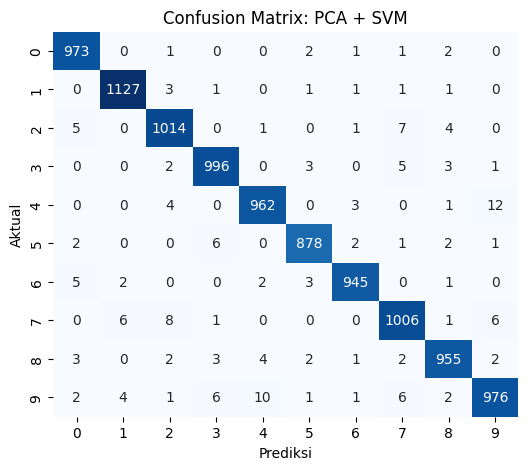

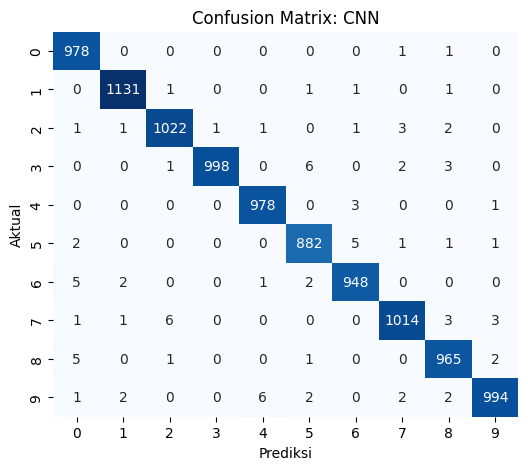

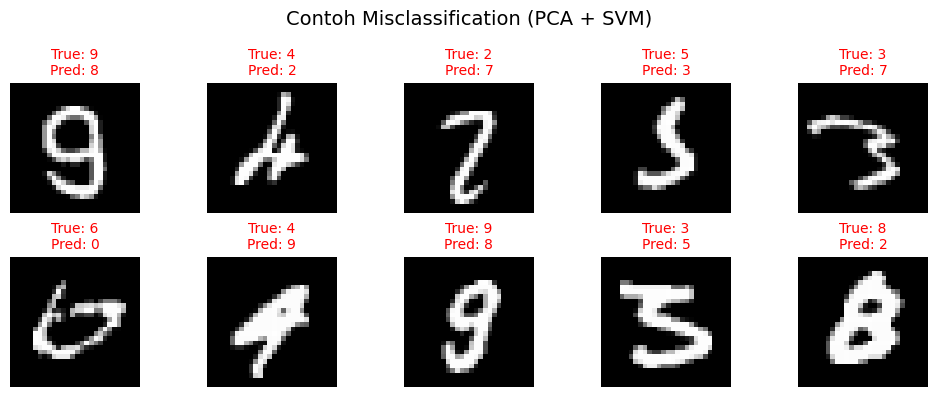

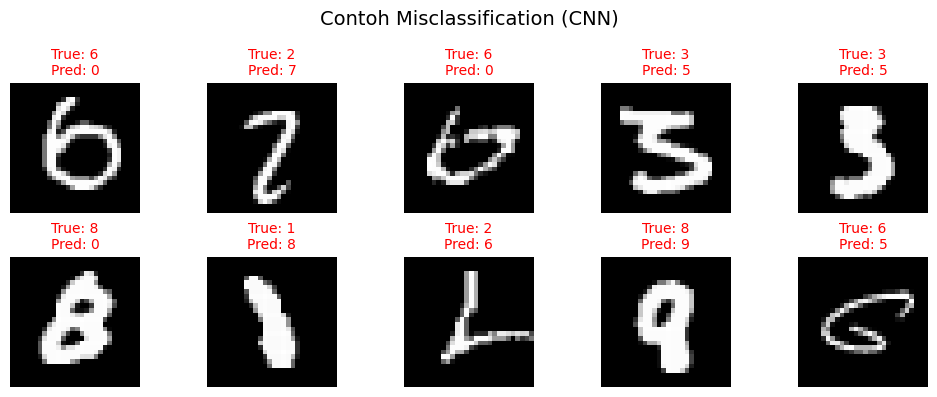

In [ ]:
# Fungsi Plot Confusion Matrix
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

# Plot Confusion Matrix
plot_cm(y_test, svm_pred, 'Confusion Matrix: PCA + SVM')
plot_cm(y_test, cnn_pred, 'Confusion Matrix: CNN')

# Analisis Gambar yang Salah Klasifikasi (Misclassification)
def show_misclassified(y_true, y_pred, model_name):
    misclassified_idx = np.where(y_true != y_pred)[0]
    plt.figure(figsize=(10, 4))
    plt.suptitle(f'Contoh Misclassification ({model_name})', fontsize=14)

    for i, idx in enumerate(misclassified_idx[:10]): # Tampilkan 10 kesalahan pertama
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_test[idx], cmap='gray')
        plt.title(f'True: {y_true[idx]}\nPred: {y_pred[idx]}', color='red', fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_misclassified(y_test, svm_pred, 'PCA + SVM')
show_misclassified(y_test, cnn_pred, 'CNN')